# SmartCHDR — Dataset Generation Notebook

## Purpose
This notebook documents the generation of synthetic datasets for:
- **Model 1:** Growth and Weight Predictor
- **Model 2:** Nutrition Needs Predictor

## Data Source
All data is generated from official **WHO Child Growth Standards** reference tables:
- Length/Height-for-age: Boys and Girls (0–5 years)
- Weight-for-age: Boys and Girls (0–5 years)

## Why Synthetic Data?
The WHO reference tables provide scientifically validated median values and 
standard deviations for every month from 0 to 60 months. By sampling from 
these distributions, we generate a dataset that is 100% traceable to official 
WHO standards with accurate growth status labels.

**Author:** Anugi Fernando  
**Project:** SmartCHDR Final Year Project  
**Date:** May 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries imported successfully!


In [3]:
import subprocess
subprocess.run(["pip", "install", "openpyxl"], check=True)
print("✅ openpyxl installed!")

✅ openpyxl installed!


In [4]:
# Define path to your WHO datasets folder
WHO_PATH = "../datasets/model1_growth/"

# Load height-for-age files
lhfa_boys_0_2  = pd.read_excel(WHO_PATH + "lhfa_boys_0_2.xlsx")
lhfa_boys_2_5  = pd.read_excel(WHO_PATH + "lhfa_boys_2_5.xlsx")
lhfa_girls_0_2 = pd.read_excel(WHO_PATH + "lhfa_girls_0_2.xlsx")
lhfa_girls_2_5 = pd.read_excel(WHO_PATH + "lhfa_girls_2_5.xlsx")

# Load weight-for-age files
wfa_boys  = pd.read_excel(WHO_PATH + "wfa_boys_0_5.xlsx")
wfa_girls = pd.read_excel(WHO_PATH + "wfa_girls_0_5.xlsx")

# Strip whitespace from column names
for df in [lhfa_boys_0_2, lhfa_boys_2_5, lhfa_girls_0_2, 
           lhfa_girls_2_5, wfa_boys, wfa_girls]:
    df.columns = df.columns.str.strip()

print("✅ All 6 WHO files loaded successfully!")
print(f"Height boys rows: {len(lhfa_boys_0_2) + len(lhfa_boys_2_5) - 1}")
print(f"Height girls rows: {len(lhfa_girls_0_2) + len(lhfa_girls_2_5) - 1}")
print(f"Weight boys rows: {len(wfa_boys)}")
print(f"Weight girls rows: {len(wfa_girls)}")

✅ All 6 WHO files loaded successfully!
Height boys rows: 61
Height girls rows: 61
Weight boys rows: 61
Weight girls rows: 61


In [5]:
# Combine height files (remove duplicate month 24)
lhfa_boys_full  = pd.concat([lhfa_boys_0_2, lhfa_boys_2_5.iloc[1:]], 
                              ignore_index=True)
lhfa_girls_full = pd.concat([lhfa_girls_0_2, lhfa_girls_2_5.iloc[1:]], 
                              ignore_index=True)

# Rename columns for height tables
for df in [lhfa_boys_full, lhfa_girls_full]:
    df.rename(columns={'Month': 'month', 'M': 'median', 'SD': 'sd'}, inplace=True)

# Rename columns for weight tables and calculate SD = median × CV
for df in [wfa_boys, wfa_girls]:
    df.rename(columns={'Month': 'month', 'M': 'median', 'S': 'cv'}, inplace=True)
    df['sd'] = df['median'] * df['cv']

print("✅ Reference tables built!")
print(f"Height boys: month {lhfa_boys_full['month'].min()} to {lhfa_boys_full['month'].max()}")
print(f"Height girls: month {lhfa_girls_full['month'].min()} to {lhfa_girls_full['month'].max()}")
print(f"Weight boys: month {wfa_boys['month'].min()} to {wfa_boys['month'].max()}")
print(f"Weight girls: month {wfa_girls['month'].min()} to {wfa_girls['month'].max()}")

✅ Reference tables built!
Height boys: month 0 to 60
Height girls: month 0 to 60
Weight boys: month 0 to 60
Weight girls: month 0 to 60


In [6]:
def get_who_reference(month, gender, measure):
    """Get WHO median and SD for a given month, gender and measure."""
    if measure == 'height':
        ref = lhfa_boys_full if gender == 'male' else lhfa_girls_full
    else:
        ref = wfa_boys if gender == 'male' else wfa_girls
    row = ref[ref['month'] == month].iloc[0]
    return float(row['median']), float(row['sd'])

def calculate_zscore(value, median, sd):
    """Calculate WHO z-score: (value - median) / SD"""
    return round((value - median) / sd, 2)

def classify_growth_status(waz, haz):
    """
    Classify child growth status using WHO thresholds.
    Priority: stunted > underweight > overweight > normal
    """
    if haz < -2:
        return 'stunted'
    elif waz < -2:
        return 'underweight'
    elif waz > 2:
        return 'overweight'
    else:
        return 'normal'

def classify_nutrition_risk(waz, haz):
    """
    Classify nutrition risk level based on WHO z-score thresholds.
    high = either zscore below -2
    moderate = either zscore below -1
    low = both zscores above -1
    """
    if waz < -2 or haz < -2:
        return 'high'
    elif waz < -1 or haz < -1:
        return 'moderate'
    else:
        return 'low'

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [7]:
CHILDREN_PER_MONTH = 100  # 100 × 61 months × 2 genders = 12,200 records
records = []

for gender in ['male', 'female']:
    for month in range(0, 61):
        h_median, h_sd = get_who_reference(month, gender, 'height')
        w_median, w_sd = get_who_reference(month, gender, 'weight')

        for _ in range(CHILDREN_PER_MONTH):
            # Sample z-scores — slight negative skew reflects Sri Lankan/
            # South Asian child population (some degree of undernutrition)
            haz = round(np.clip(np.random.normal(-0.5, 1.3), -4, 4), 2)
            waz = round(np.clip(np.random.normal(-0.3, 1.2), -4, 4), 2)

            # Calculate actual measurements from z-scores
            height_cm = round(max(h_median + haz * h_sd, h_median * 0.75), 1)
            weight_kg = round(max(w_median + waz * w_sd, 1.5), 2)

            # Recalculate z-scores from actual values for consistency
            haz_final = calculate_zscore(height_cm, h_median, h_sd)
            waz_final = calculate_zscore(weight_kg, w_median, w_sd)

            records.append({
                'age_months'        : month,
                'gender'            : gender,
                'weight_kg'         : weight_kg,
                'height_cm'         : height_cm,
                'weight_median_who' : round(w_median, 3),
                'height_median_who' : round(h_median, 3),
                'weight_zscore'     : waz_final,
                'height_zscore'     : haz_final,
                'growth_status'     : classify_growth_status(waz_final, haz_final),
                'nutrition_risk'    : classify_nutrition_risk(waz_final, haz_final),
            })

df = pd.DataFrame(records)
print(f"✅ Dataset generated: {len(df):,} records")
print(f"\nGrowth status distribution:")
print(df['growth_status'].value_counts())
print(f"\nNutrition risk distribution:")
print(df['nutrition_risk'].value_counts())

✅ Dataset generated: 12,200 records

Growth status distribution:
growth_status
normal         9632
stunted        1496
underweight     801
overweight      271
Name: count, dtype: int64

Nutrition risk distribution:
nutrition_risk
low         5760
moderate    4143
high        2297
Name: count, dtype: int64


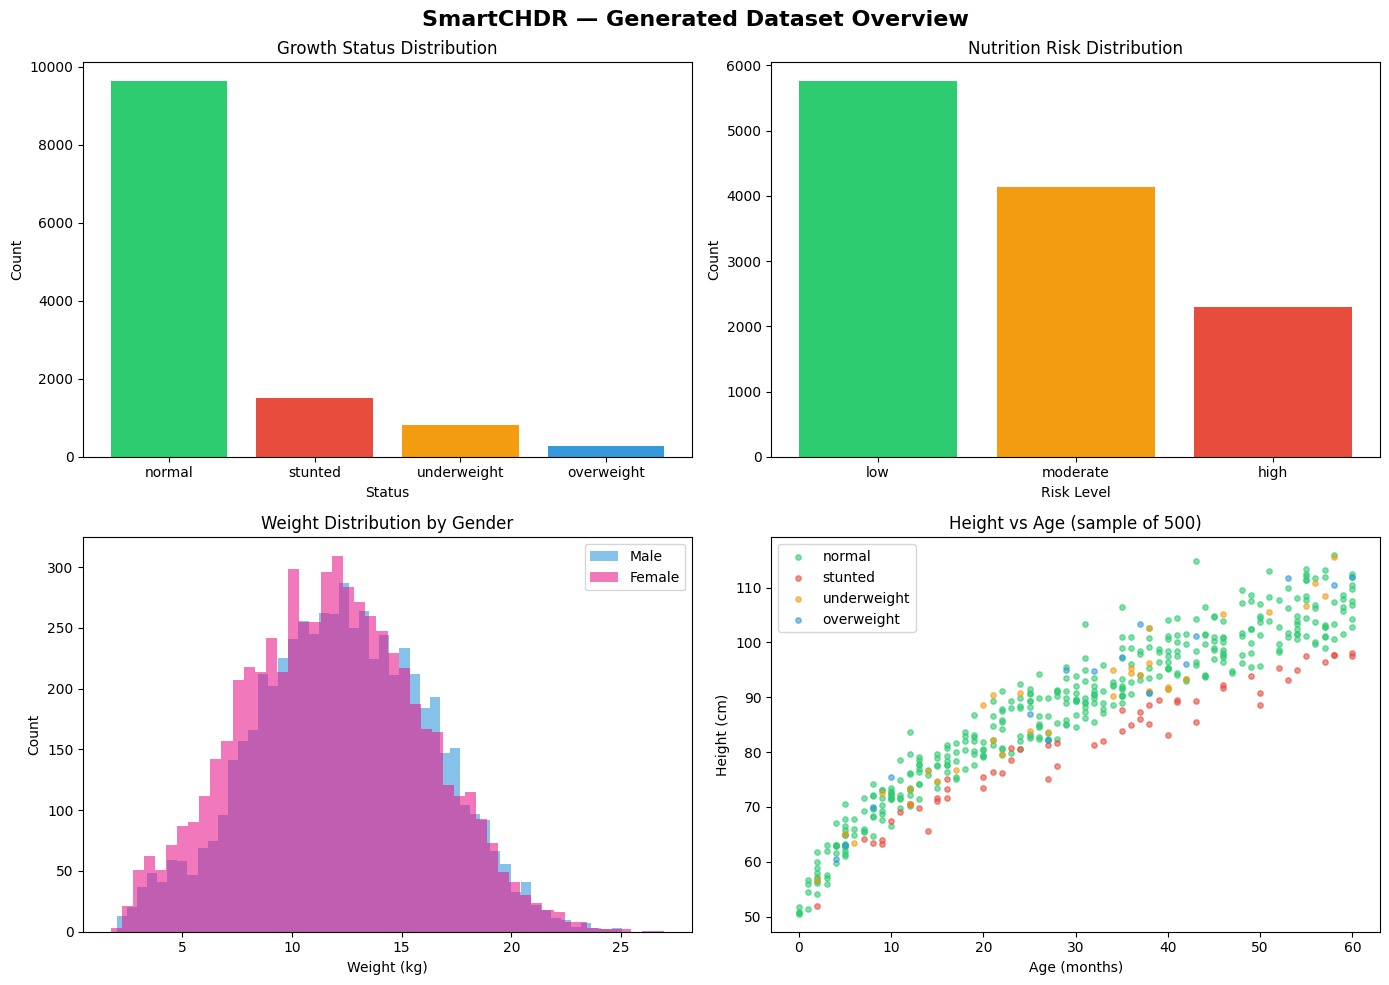

✅ Charts saved to datasets/dataset_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartCHDR — Generated Dataset Overview', fontsize=16, fontweight='bold')

# Chart 1: Growth status distribution
axes[0,0].bar(df['growth_status'].value_counts().index, 
              df['growth_status'].value_counts().values,
              color=['#2ecc71','#e74c3c','#f39c12','#3498db'])
axes[0,0].set_title('Growth Status Distribution')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')

# Chart 2: Nutrition risk distribution
axes[0,1].bar(df['nutrition_risk'].value_counts().index,
              df['nutrition_risk'].value_counts().values,
              color=['#2ecc71','#f39c12','#e74c3c'])
axes[0,1].set_title('Nutrition Risk Distribution')
axes[0,1].set_xlabel('Risk Level')
axes[0,1].set_ylabel('Count')

# Chart 3: Weight distribution by gender
axes[1,0].hist(df[df['gender']=='male']['weight_kg'], bins=50, 
               alpha=0.6, label='Male', color='#3498db')
axes[1,0].hist(df[df['gender']=='female']['weight_kg'], bins=50, 
               alpha=0.6, label='Female', color='#e91e8c')
axes[1,0].set_title('Weight Distribution by Gender')
axes[1,0].set_xlabel('Weight (kg)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Chart 4: Height vs Age scatter
sample = df.sample(500)
colors = {'normal':'#2ecc71','stunted':'#e74c3c',
          'underweight':'#f39c12','overweight':'#3498db'}
for status, color in colors.items():
    subset = sample[sample['growth_status']==status]
    axes[1,1].scatter(subset['age_months'], subset['height_cm'], 
                      c=color, label=status, alpha=0.6, s=15)
axes[1,1].set_title('Height vs Age (sample of 500)')
axes[1,1].set_xlabel('Age (months)')
axes[1,1].set_ylabel('Height (cm)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../datasets/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to datasets/dataset_overview.png")

In [9]:
# Create output folders if they don't exist
os.makedirs('../datasets/model1_growth', exist_ok=True)
os.makedirs('../datasets/model2_nutrition', exist_ok=True)

# Save Model 1 — Growth dataset
model1_cols = ['age_months','gender','weight_kg','height_cm',
               'weight_median_who','height_median_who',
               'weight_zscore','height_zscore','growth_status']
df[model1_cols].to_csv('../datasets/model1_growth/model1_growth_dataset.csv', 
                        index=False)

# Save Model 2 — Nutrition dataset
model2_cols = ['age_months','gender','weight_kg','height_cm',
               'weight_zscore','height_zscore','nutrition_risk']
df[model2_cols].to_csv('../datasets/model2_nutrition/model2_nutrition_dataset.csv', 
                        index=False)

print("✅ Datasets saved!")
print(f"\nModel 1 saved to: datasets/model1_growth/model1_growth_dataset.csv")
print(f"Rows: {len(df[model1_cols]):,} | Columns: {len(model1_cols)}")
print(f"\nModel 2 saved to: datasets/model2_nutrition/model2_nutrition_dataset.csv")
print(f"Rows: {len(df[model2_cols]):,} | Columns: {len(model2_cols)}")

✅ Datasets saved!

Model 1 saved to: datasets/model1_growth/model1_growth_dataset.csv
Rows: 12,200 | Columns: 9

Model 2 saved to: datasets/model2_nutrition/model2_nutrition_dataset.csv
Rows: 12,200 | Columns: 7


## Dataset Generation Complete ✅

### Model 1 — Growth Dataset
- **File:** `datasets/model1_growth/model1_growth_dataset.csv`
- **Records:** 12,200
- **Columns:** age_months, gender, weight_kg, height_cm, weight_median_who, height_median_who, weight_zscore, height_zscore, growth_status
- **Labels:** normal, stunted, underweight, overweight
- **Source:** WHO Child Growth Standards (official reference tables)

### Model 2 — Nutrition Dataset
- **File:** `datasets/model2_nutrition/model2_nutrition_dataset.csv`
- **Records:** 12,200
- **Columns:** age_months, gender, weight_kg, height_cm, weight_zscore, height_zscore, nutrition_risk
- **Labels:** low, moderate, high
- **Source:** WHO z-score thresholds per WHO/UNICEF nutrition guidelines

### Notes
- Random seed set to 42 for full reproducibility
- Z-score distribution uses slight negative skew (mean -0.5 for height, -0.3 for weight) reflecting South Asian child population patterns
- All classifications follow official WHO thresholds (z-score < -2 = at risk)